# Handwritten Digit Classification with ANN — MNIST Dataset
---

> A complete deep learning pipeline for classifying handwritten digits (0-9)
> using an Artificial Neural Network (ANN) built with PyTorch.
> Covers data loading, model architecture, training, evaluation, and visualization.

---

## Topics

| # | Topic | Tool/Concept |
|---|-------|-------------|
| 1 | Setup & Imports | PyTorch, sklearn, matplotlib |
| 2 | Device Configuration | CPU vs GPU |
| 3 | Hyperparameters | Learning rate, batch size, epochs |
| 4 | Data Loading | MNIST via torchvision |
| 5 | ANN Architecture | nn.Sequential, ReLU |
| 6 | Loss & Optimizer | CrossEntropyLoss, Adam |
| 7 | Training Loop | Forward pass, backpropagation |
| 8 | Evaluation | Accuracy, Precision, Recall, Confusion Matrix |
| 9 | Visualization | Accuracy curve over epochs |

---

## Dataset — MNIST

| Property | Value |
|----------|-------|
| Training samples | 60,000 |
| Test samples | 10,000 |
| Image size | 28 x 28 pixels |
| Classes | 10 (digits 0 to 9) |
| Color | Grayscale |

## Step 1 — Imports

We import all required libraries upfront:
- `torch`, `torch.nn`, `torch.optim` — model building, loss, and optimization
- `torchvision` — MNIST dataset and image transforms
- `sklearn` — evaluation metrics (accuracy, precision, recall, confusion matrix)
- `matplotlib` — plotting accuracy curves

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    roc_curve,
    roc_auc_score,
)


## Step 2 — Device Configuration

PyTorch can run on **CPU** or **GPU (CUDA)**.
Training on a GPU is significantly faster for deep learning tasks.

This line automatically selects GPU if available, otherwise falls back to CPU:

- `cuda` — NVIDIA GPU (much faster for large models)
- `cpu` — standard processor (slower but always available)

In [2]:
# Use GPU if available, otherwise fall back to CPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cpu')



## Step 3 — Hyperparameters

Hyperparameters control the structure and training behavior of the model.
They are set before training and are not learned from data.

| Hyperparameter | Value | Meaning |
|---------------|-------|---------|
| `input_size` | 784 | 28 x 28 pixels flattened into a vector |
| `hidden_size1` | 256 | neurons in the first hidden layer |
| `hidden_size2` | 128 | neurons in the second hidden layer |
| `num_classes` | 10 | output classes (digits 0-9) |
| `learning_rate` | 0.003 | step size for weight updates |
| `batch_size` | 64 | images processed per iteration |
| `num_epochs` | 10 | full passes through the training data |

In [3]:
input_size = 28 * 28    # flatten 28x28 image into a 784-dim vector
hidden_size1 = 256      # neurons in first hidden layer
hidden_size2 = 128      # neurons in second hidden layer
num_classes = 10        # 10 digit classes (0-9)
learning_rate = 0.003   # Adam optimizer step size
batch_size = 64         # images per training batch
num_epochs = 10         # total training epochs


## Step 4 — Load MNIST Dataset

We load the MNIST dataset using `torchvision.datasets.MNIST`.

`transforms.ToTensor()` converts each PIL image to a PyTorch tensor
and normalizes pixel values from $[0, 255]$ to $[0.0, 1.0]$:

$$\text{tensor} = \frac{\text{pixel}}{255}$$

- `train=True` loads the 60,000 training images
- `train=False` loads the 10,000 test images

In [4]:
transform = transforms.ToTensor()

# Load training dataset
train_dataset = datasets.MNIST(
    root="./data",
    train=True,
    transform=transform,
    download=True
)

# Load test dataset
test_dataset = datasets.MNIST(
    root="./data",
    train=False,
    transform=transform,
    download=True
)

100%|██████████| 9.91M/9.91M [00:00<00:00, 42.4MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.20MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 10.6MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 7.22MB/s]



## Step 5 — Check Dataset Size

A quick sanity check to confirm both datasets loaded correctly.
Expected output: `(60000, 10000)`


In [5]:
# Print number of training and test samples
len(train_dataset), len(test_dataset)

(60000, 10000)


## Step 6 — Create DataLoaders

`DataLoader` wraps the dataset and handles batching, shuffling, and iteration.

| Parameter | Train | Test |
|-----------|-------|------|
| `batch_size` | 64 | 64 |
| `shuffle` | True | False |

- Train loader is **shuffled** so the model does not memorize order
- Test loader is **not shuffled** since we only evaluate, not train

$$\text{Train batches} = \frac{60000}{64} = 937 \text{ batches}$$
$$\text{Test batches} = \frac{10000}{64} = 156 \text{ batches}$$

In [6]:
# Training DataLoader — shuffled for better generalization
train_loader = DataLoader(
    dataset=train_dataset,
    batch_size=batch_size,
    shuffle=True
)

# Test DataLoader — no shuffle needed for evaluation
test_loader = DataLoader(
    dataset=test_dataset,
    batch_size=batch_size,
    shuffle=False
)


## Step 7 — Define the ANN Architecture

We build a **3-layer Artificial Neural Network** using `nn.Sequential`.

### Network Architecture

Input      →  [784]
               |
           Linear(784 → 256)
               |
             ReLU
               |
           Linear(256 → 128)
               |
             ReLU
               |
           Linear(128 → 10)
               |
Output     →  [10 classes]

### Why ReLU?

ReLU (Rectified Linear Unit) introduces non-linearity so the network
can learn complex patterns beyond simple linear relationships:

$$\text{ReLU}(x) = \max(0, x)$$

### Why nn.Flatten()?

Input images have shape `[batch, 1, 28, 28]`.
`nn.Flatten()` converts them to `[batch, 784]` — required for Linear layers.

In [7]:
from os import name

class ANN(nn.Module):
  def __init__(self):
    super(ANN, self).__init__()
    # self.fc1 = nn.Linear(input_size, hidden_size1)
    # self.fc2 = nn.Linear(hidden_size1, hidden_size2)
    # self.fc3 = nn.Linear(hidden_size2, num_classes)
    self.network = nn.Sequential(
        nn.Flatten(),                               # [batch, 1, 28, 28] -> [batch, 784]
        nn.Linear(input_size, hidden_size1),        # 784 -> 256
        nn.ReLU(),                                  # non-linear activation
        nn.Linear(hidden_size1, hidden_size2),      # 256 -> 128
        nn.ReLU(),                                  # non-linear activation
        nn.Linear(hidden_size2, num_classes)        # 128 -> 10 (output logits)
    )

  def forward(self, x):
    output = self.network(x)
    return output



### Function Version

```
from os import name

class ANN(nn.Module):
  def __init__(self):
    super(ANN, self).__init__()
    self.fc1 = nn.Linear(input_size, hidden_size1)
    self.fc2 = nn.Linear(hidden_size1, hidden_size2)
    self.fc3 = nn.Linear(hidden_size2, num_classes)

  def forward(self, x):
    x = x.view(-1, input_size)   # flatten: [batch, 1, 28, 28] -> [batch, 784]
    x = torch.relu(self.fc1(x))  # 784 -> 256 + ReLU
    x = torch.relu(self.fc2(x))  # 256 -> 128 + ReLU
    output = self.fc3(x)         # 128 -> 10 (output logits)
    return output
```





## Step 8 — Initialize Model on Device

We create an instance of ANN and move it to the selected device (CPU or GPU).
`.to(device)` ensures all model weights are stored on the correct hardware.

In [8]:
# Instantiate model and move to device
model = ANN().to(device)


## Step 9 — Loss Function and Optimizer

### Loss Function — CrossEntropyLoss

For multi-class classification, we use **Cross-Entropy Loss**:

$$\mathcal{L} = -\sum_{c=1}^{C} y_c \log(\hat{y}_c)$$

It measures how far the predicted probability distribution is from the true label.

### Optimizer — Adam

**Adam** (Adaptive Moment Estimation) adjusts the learning rate for each parameter automatically.
It is faster and more stable than plain SGD for most deep learning tasks.

In [ ]:
# CrossEntropyLoss for multi-class classification
criterion = nn.CrossEntropyLoss()

# Adam optimizer — adaptive learning rate
# optimizer = optim.Adam(model.parameters(), lr=learning_rate, weight_decay=0.001)
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

`weight_decay` is a form of **L2 Regularization** — it prevents the model from **overfitting**.

During training, it stops the model's weights from growing too large. When weights become too large, the model starts **memorizing** the training data instead of learning general patterns — which causes poor performance on new unseen data.

`weight_decay=0.001` means after every weight update, all weights are slightly **shrunk** toward zero to keep them in check.



## Step 10 — Count Total Trainable Parameters

Before training, we check how many parameters (weights + biases) the model has.
This gives a sense of model complexity and memory usage.

Expected calculation:
- Layer 1: 784 x 256 + 256 = 200,960
- Layer 2: 256 x 128 + 128 = 32,896
- Layer 3: 128 x 10 + 10 = 1,290
- **Total: 235,146 parameters**

In [9]:
# Count total number of learnable parameters
total_params = sum(p.numel() for p in model.parameters())
print(f"Total Parameters: {total_params:,}")

Total Parameters: 235,146



## Step 11 — Inspect Parameters Per Layer

We loop through all model parameters to see the size of each layer's weights and biases individually.
`p.numel()` returns the total number of elements in that parameter tensor.

In [12]:
# Print size of each parameter tensor in the model
for p in model.parameters():
    print(p.name ,p.numel())

None 200704
None 256
None 32768
None 128
None 1280
None 10



## Step 12 — Training Loop

This is the core of model training. For each epoch:

1. **Forward pass** — input flows through the network to produce predictions
2. **Loss calculation** — compare predictions to true labels
3. **Backward pass** — compute gradients via backpropagation
4. **Weight update** — optimizer adjusts weights to reduce loss

### Training Flow

images -> model -> outputs -> loss
                                |
                         loss.backward()
                                |
                         optimizer.step()

At the end of each epoch, we also evaluate on the **test set** (no gradient computation needed).

In [13]:
# Loss function and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

# Training loop
train_acc_list = []
test_acc_list = []

for epoch in range(num_epochs):
    model.train()  # set model to training mode

    correct = 0
    total = 0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        # forward pass
        outputs = model(images)
        loss = criterion(outputs, labels)

        # backward propagation
        optimizer.zero_grad()   # clear old gradients
        loss.backward()         # compute new gradients
        optimizer.step()        # update weights

        # track training accuracy
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    train_accuracy = 100 * correct / total
    train_acc_list.append(train_accuracy)

    # evaluation on test set
    model.eval()  # set model to evaluation mode
    correct = 0
    total = 0

    with torch.no_grad():  # no gradient needed during evaluation
        for images, labels in test_loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    test_accuracy = 100 * correct / total
    test_acc_list.append(test_accuracy)

    print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item():.4f}, Train Accuracy: {train_accuracy:.2f}%, Test Accuracy: {test_accuracy:.2f}%")

Epoch [1/10], Loss: 0.1870, Train Accuracy: 93.31%, Test Accuracy: 96.29%
Epoch [2/10], Loss: 0.1098, Train Accuracy: 96.97%, Test Accuracy: 97.38%
Epoch [3/10], Loss: 0.0797, Train Accuracy: 97.75%, Test Accuracy: 97.23%
Epoch [4/10], Loss: 0.0104, Train Accuracy: 98.26%, Test Accuracy: 97.36%
Epoch [5/10], Loss: 0.0167, Train Accuracy: 98.48%, Test Accuracy: 97.79%
Epoch [6/10], Loss: 0.0886, Train Accuracy: 98.71%, Test Accuracy: 97.76%
Epoch [7/10], Loss: 0.0574, Train Accuracy: 98.88%, Test Accuracy: 97.83%
Epoch [8/10], Loss: 0.0013, Train Accuracy: 98.99%, Test Accuracy: 97.38%
Epoch [9/10], Loss: 0.0021, Train Accuracy: 99.03%, Test Accuracy: 97.66%
Epoch [10/10], Loss: 0.0007, Train Accuracy: 99.24%, Test Accuracy: 97.18%



## Step 13 — Collect Predictions for Evaluation

After training, we run the model on the full test set and collect all predictions.
We use `torch.no_grad()` to disable gradient computation — saves memory and speeds up inference.

The results are converted to numpy arrays for use with sklearn's metric functions.

In [14]:
from torch.return_types import all_return_types

model.eval()  # evaluation mode

all_labels = []
all_predictions = []

with torch.no_grad():
    for images, labels in test_loader:
      images = images.to(device)
      labels = labels.to(device)

      outputs = model(images)

      _, predicted = torch.max(outputs.data, 1)

      # collect true labels and predictions
      all_labels.extend(labels.cpu().numpy())
      all_predictions.extend(predicted.cpu().numpy())


# compute evaluation metrics
accuracy = accuracy_score(all_labels, all_predictions)
precision = precision_score(all_labels, all_predictions, average='weighted')
recall = recall_score(all_labels, all_predictions, average='weighted')
confusion = confusion_matrix(all_labels, all_predictions)



## Step 14 — Print Evaluation Metrics

We print the final evaluation scores on the test set.

| Metric | Formula | What It Measures |
|--------|---------|-----------------|
| Accuracy | $\frac{TP + TN}{Total}$ | Overall correct predictions |
| Precision | $\frac{TP}{TP + FP}$ | Of predicted positives, how many are correct |
| Recall | $\frac{TP}{TP + FN}$ | Of actual positives, how many were found |
| Confusion Matrix | $C_{ij}$ | Per-class prediction breakdown |

In [15]:
print(f"Accuracy: {accuracy:.2f}")
print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")
print("Confusion Matrix:")
print(confusion)

Accuracy: 0.97
Precision: 0.97
Recall: 0.97
Confusion Matrix:
[[ 972    0    2    1    0    1    2    1    1    0]
 [   0 1113    8    3    0    3    2    3    3    0]
 [   4    1 1009    3    0    0    4    8    3    0]
 [   1    0    5  958    0   32    0    8    2    4]
 [   1    3    8    0  946    0    5    6    0   13]
 [   5    0    0    1    1  878    2    1    2    2]
 [   7    2    1    0    4    5  936    0    2    1]
 [   3    2    8    1    4    0    0 1000    2    8]
 [  16    0    5    5    3    7    3    3  926    6]
 [   6    3    2    0    8    3    0    3    4  980]]




## Step 15 — Plot Accuracy Curve

We plot **Train Accuracy** and **Test Accuracy** over all epochs.

- If both curves rise together — the model is learning well
- If train accuracy is high but test accuracy is low — the model is **overfitting**
- A small gap between the two is normal and acceptable

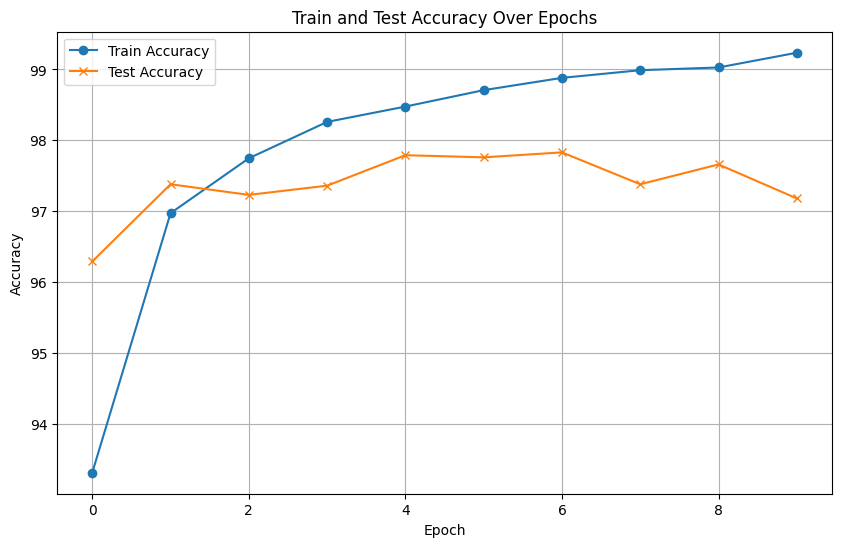

In [20]:
plt.figure(figsize=(10, 6))
plt.plot(train_acc_list, label='Train Accuracy',marker='o')
plt.plot(test_acc_list, label='Test Accuracy', marker='x')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Train and Test Accuracy Over Epochs')
plt.legend()
plt.grid(True)
plt.show()


## Step 16 — Confusion Matrix Heatmap

A **heatmap** is a more visual and readable way to display the confusion matrix
compared to raw numbers.

- Each row represents the **actual class**
- Each column represents the **predicted class**
- The diagonal cells (top-left to bottom-right) show **correct predictions**
- Off-diagonal cells show **misclassifications**

`annot=True` prints the count inside each cell.
`fmt='d'` formats the numbers as integers.
`cmap='Blues'` uses a blue color scale — darker means higher count.

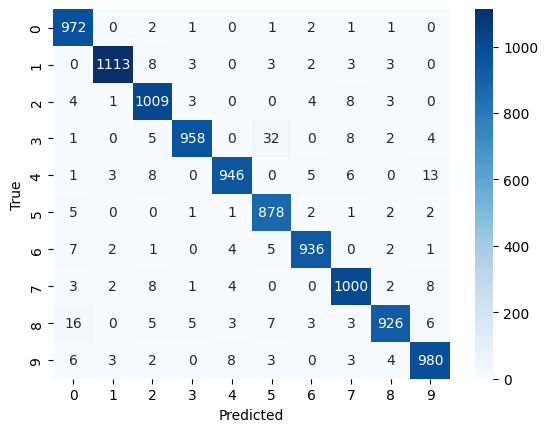

In [18]:
import seaborn as sns
sns.heatmap(confusion, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

## Conclusion & Key Takeaways

### Summary

| Step | What We Did |
|------|------------|
| Imports | Loaded PyTorch, torchvision, sklearn, matplotlib |
| Device Setup | Auto-selected GPU or CPU |
| Hyperparameters | Defined architecture size, learning rate, batch size, epochs |
| Data Loading | MNIST — 60,000 train / 10,000 test images |
| ANN Architecture | 3 Linear layers with ReLU activations |
| Loss + Optimizer | CrossEntropyLoss + Adam |
| Training | 10 epochs with forward + backward pass |
| Evaluation | Accuracy, Precision, Recall, Confusion Matrix |
| Visualization | Train vs Test accuracy curve |

---

### Key Takeaways

1. **Flatten** converts 2D images into 1D vectors for Linear layers
2. **ReLU** adds non-linearity so the network learns complex patterns
3. **CrossEntropyLoss** is the standard loss for multi-class classification
4. **Adam** is preferred over SGD for faster and more stable convergence
5. **torch.no_grad()** must be used during evaluation to save memory
6. A small gap between train and test accuracy means the model generalizes well

